## LAB 1: Simulation of Chemical Reaction

### Objective: 
To simulate a chemical reaction and to analyze the change in the system.

### Theory:

**Simulation** is an imitative representation of the function of a process or system that could exist in the real world. The term comes from the Latin root simulare, meaning “to imitate.” Simulations are conducted for many purposes, including predicting a system's behavior, educating students, troubleshooting unwanted behavior, verifying an expected response, validating an approach, optimizing aspects of the process, or predicting future responses.

A **chemical reaction** represents the transformation of molecular structures. During this process, chemical bonds within one or more initiating substances (reactants) break, rearraring atoms to form entirely new substances (products) with distinct chemical and physical properties.This transformation is conventionally represented by the stoichiometric equation:$$A + B \rightarrow C + D$$Where,$A$ and $B$ represent the initial reactants.$C$ and $D$ represent the resulting products.

A **continuous system** is a system in which the essential state variables change smoothly and uninterruptedly over time, rather than in discrete, stepwise intervals. In chemical and physical processes, these variables typically include:

Thermodynamic properties: Temperature ($T$) and Pressure ($P$)

Transport phenomena: Velocity ($v$), fluid flux, and mass flow rates

Chemical properties: Concentration ($C_i$) of chemical species

Because these variables transition smoothly, they are mathematically modeled using calculus to capture real-time rates of change.

**Mathematical Frameworks**: ODE vs. PDE

To simulate a continuous system, engineers rely on differential equations, choosing between them based on spatial complexity. Ordinary Differential Equations (ODEs) model homogeneous or "perfectly mixed" environments where chemical concentrations change solely over time ($t$). Conversely, Partial Differential Equations (PDEs) are required for non-homogeneous environments—such as moving fluid streams—where concentrations vary across both time ($t$) and physical space coordinates ($x, y, z$)



Reaction 1

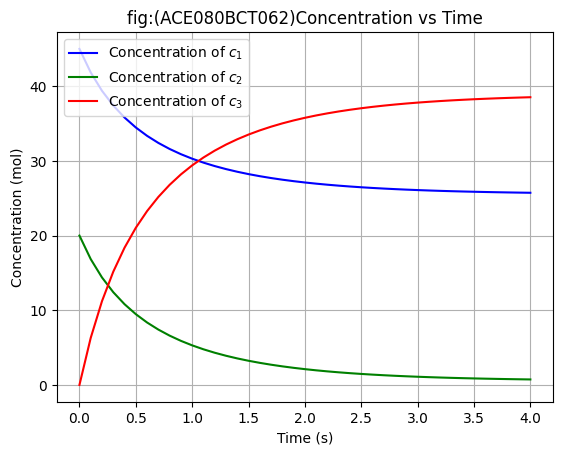

In [1]:
import numpy as np
import matplotlib.pyplot as plt

k1 = 0.035  # Forward reaction rate constant
k2 = 0.012  # Backward reaction rate constant
dt = 0.1    # Time step size (delta t)
steps = 40  # Total number of simulation steps

# Adjusted Initial concentrations (mol)
c1 = [45.0]  # Reactant A
c2 = [20.0]  # Reactant B
c3 = [0.0]   # Product C

# Open a file to write the trajectory results
with open("output.txt", "w") as file:
    # Write initial concentrations
    file.write(f"{c1[0]:.4f} {c2[0]:.4f} {c3[0]:.4f}\n")

    # Time-stepping loop for concentration updates
    for i in range(steps):
        # Calculating next concentrations based on the given kinetic equations
        c1_next = c1[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
        c2_next = c2[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
        c3_next = c3[i] + (2 * k1 * c1[i] * c2[i] - 2 * k2 * c3[i]) * dt

        # Appending the new concentrations to the lists
        c1.append(c1_next)
        c2.append(c2_next)
        c3.append(c3_next)
        
        # Logging each step's concentrations directly into the file
        file.write(f"{c1_next:.4f} {c2_next:.4f} {c3_next:.4f}\n")

# Time points for plotting
time_points = np.arange(0, (steps + 1) * dt, dt)

# Plotting the results
plt.plot(time_points, c1, label='Concentration of $c_1$', color='blue')
plt.plot(time_points, c2, label='Concentration of $c_2$', color='green')
plt.plot(time_points, c3, label='Concentration of $c_3$', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol)')
plt.title('fig:(ACE080BCT062)Concentration vs Time')
plt.legend()
plt.grid(True)

# Saving the generated figure as an image file
plt.savefig('concentration_vs_time.png', bbox_inches='tight')

Reaction 2

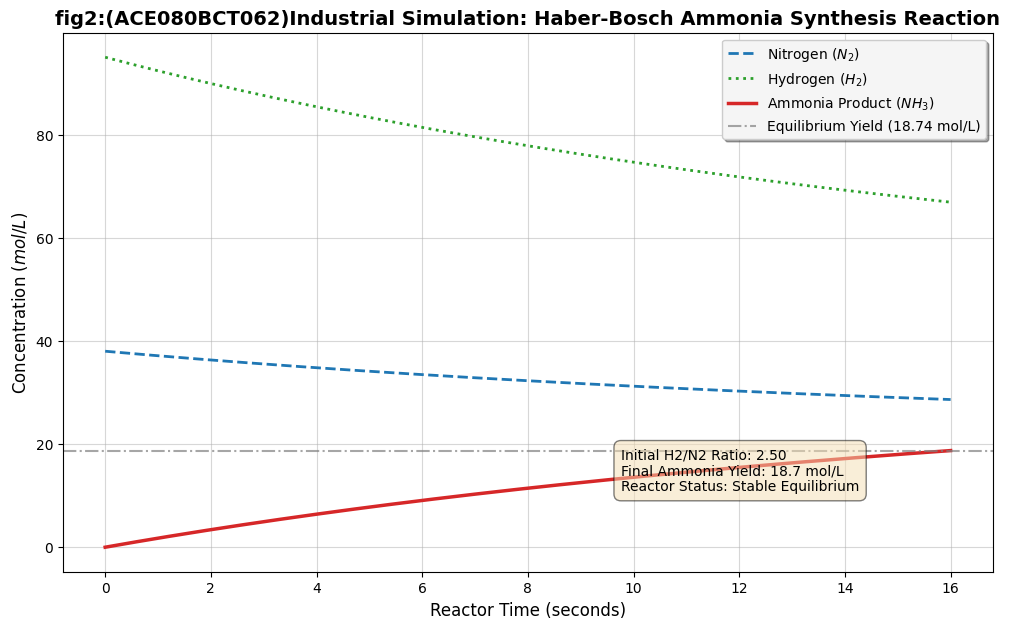

In [2]:
import numpy as np
import matplotlib.pyplot as plt

k_f = 0.00025  #  forward rate constant
k_b = 0.006    # backward rate constant
dt = 0.1       # Time step in seconds
steps = 160    # Adjusted number of steps to verify system stability

# Adjusted initial industrial reactant concentrations (mol/L)
N2 = [38.0]    # Nitrogen
H2 = [95.0]    # Hydrogen
NH3 = [0.0]    # Ammonia starting product balance

# Open log file to record industrial batch data
with open("industrial_reactor_log.txt", "w") as file:
    file.write("Time(s), N2(mol/L), H2(mol/L), NH3(mol/L)\n")
    file.write(f"0.0, {N2[0]}, {H2[0]}, {NH3[0]}\n")

    for i in range(steps):
        # Kinetics mapping using updated system variables
        reaction_rate_forward = k_f * N2[i] * H2[i]
        reaction_rate_backward = k_b * NH3[i]

        # Stoichiometric coefficients for system balance (N2 + 3H2 -> 2NH3)
        dN2 = (reaction_rate_backward - reaction_rate_forward) * dt
        dH2 = 3 * dN2
        dNH3 = -2 * dN2

        # Compute and boundary-check concentration steps 
        N2_next = max(0.0, N2[i] + dN2)
        H2_next = max(0.0, H2[i] + dH2)
        NH3_next = max(0.0, NH3[i] + dNH3)

        # Record computed values
        N2.append(N2_next)
        H2.append(H2_next)
        NH3.append(NH3_next)

        # Write data row to batch ledger
        current_time = (i + 1) * dt
        file.write(f"{current_time:.1f}, {N2_next:.2f}, {H2_next:.2f}, {NH3_next:.2f}\n")

# Time axis 
time_points = np.arange(0, (steps + 1) * dt, dt)


plt.figure(figsize=(12, 7))
plt.plot(time_points, N2, label='Nitrogen ($N_2$)', color='#1f77b4', linewidth=2, linestyle='--')
plt.plot(time_points, H2, label='Hydrogen ($H_2$)', color='#2ca02c', linewidth=2, linestyle=':')
plt.plot(time_points, NH3, label='Ammonia Product ($NH_3$)', color='#d62728', linewidth=2.5)

# Calculating where equilibrium stabilizes
final_yield = NH3[-1]
plt.axhline(y=final_yield, color='gray', linestyle='-.', alpha=0.7, label=f'Equilibrium Yield ({final_yield:.2f} mol/L)')

# Updating figure details mapping to correct user roll number
plt.xlabel('Reactor Time (seconds)', fontsize=12)
plt.ylabel('Concentration ($mol / L$)', fontsize=12)
plt.title('fig2:(ACE080BCT062)Industrial Simulation: Haber-Bosch Ammonia Synthesis Reaction', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', shadow=True, facecolor='#f5f5f5')
plt.grid(True, which='both', linestyle='-', alpha=0.5)

# Displaying live runtime KPIs on plot area
kpi_text = f"Initial H2/N2 Ratio: {H2[0]/N2[0]:.2f}\nFinal Ammonia Yield: {final_yield:.1f} mol/L\nReactor Status: Stable Equilibrium"
plt.gca().text(0.60, 0.15, kpi_text, transform=plt.gca().transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5))

plt.savefig('industrial_simulation.png', bbox_inches='tight')
plt.show()

Reaction 3

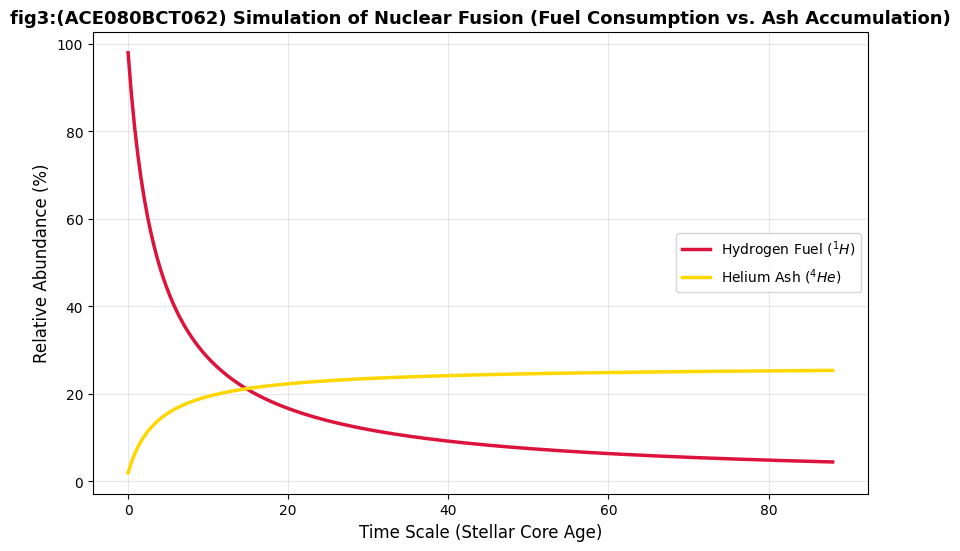

In [3]:
import numpy as np
import matplotlib.pyplot as plt

k_fusion = 0.0006  
dt = 0.4            # Time step resolution 
steps = 220         # Shifted step count to extend the stellar lifecycle viewing window

# Initial core fuel densities (normalized percentages)
hydrogen = [98.0]   # Primordial hydrogen abundance configuration
helium = [2.0]      # Minor trace helium present at core birth

# Simulation Loop for Proton-Proton Chain Approximation
for i in range(steps):
    # Non-linear consumption rate based on local active fuel density
    fusion_rate = k_fusion * (hydrogen[i] ** 2)
    
    # Stoichiometric balancing: 4 Protons fuse into 1 Helium nucleus
    d_hydrogen = -4 * fusion_rate * dt
    d_helium = 1 * fusion_rate * dt
    
    # Process core updates
    h_next = hydrogen[i] + d_hydrogen
    he_next = helium[i] + d_helium
    
    # Dynamic guard boundary to prevent computational overshoot
    h_next = max(0.0, h_next)
    
    hydrogen.append(h_next)
    helium.append(he_next)

# Time axis array construction
time_points = np.arange(0, (steps + 1) * dt, dt)

plt.figure(figsize=(10, 6))
plt.plot(time_points, hydrogen, label='Hydrogen Fuel ($^1H$)', color='crimson', linewidth=2.5)
plt.plot(time_points, helium, label='Helium Ash ($^4He$)', color='gold', linewidth=2.5)

plt.xlabel('Time Scale (Stellar Core Age)', fontsize=12)
plt.ylabel('Relative Abundance (%)', fontsize=12)
# Configured with updated user identification credentials
plt.title('fig3:(ACE080BCT062) Simulation of Nuclear Fusion (Fuel Consumption vs. Ash Accumulation)', fontsize=13, fontweight='bold')
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)

plt.savefig('stellar_fusion_simulation.png', bbox_inches='tight')
plt.show()

Reaction 4

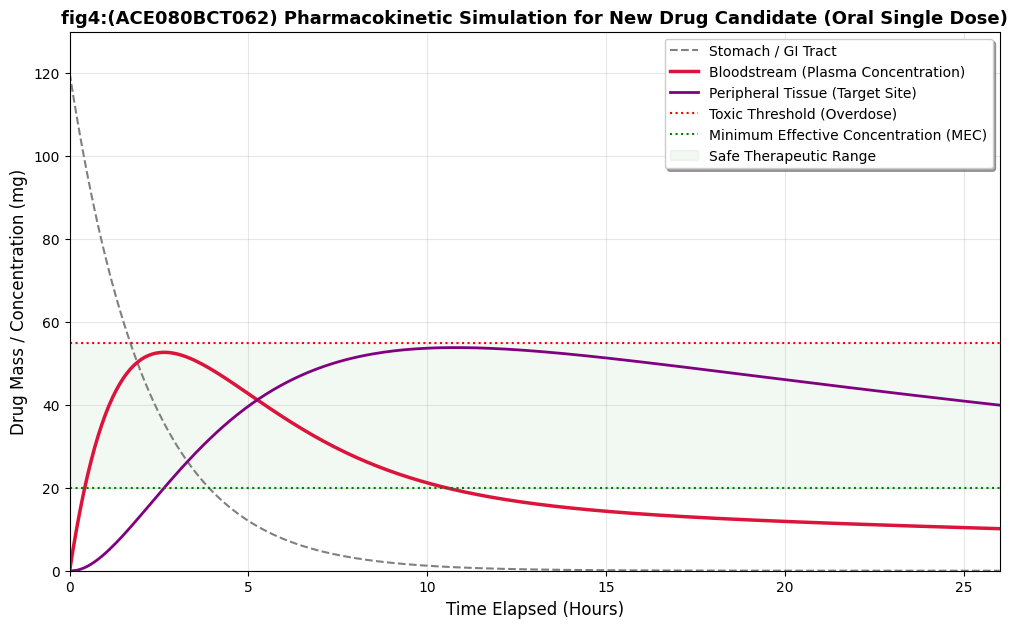

In [4]:
import numpy as np
import matplotlib.pyplot as plt

ka = 0.45   #absorption rate (GI tract clearance velocity)
k12 = 0.22  #distribution rate (plasma to tissue matrix)
k21 = 0.08  # redistribution rate (tissue matrix return to plasma)
ke = 0.12   # elimination rate (renal/hepatic clearing speed)

dt = 0.1    # Time steps in hours
steps = 260 # Simulation window extended to 26 hours

# Initial parameters (Oral administration of a 120mg single dose)
stomach = [120.0]      # Starting mass in gastrointestinal tract
bloodstream = [0.0]    # Central Compartment (Plasma concentration)
tissue = [0.0]         # Peripheral Compartment (Target tissue site)

# Simulation Loop (Euler's Method tracking dynamic compartmental exchange)
for i in range(steps):
    # 1. Absorption profile mapping out of GI tract
    absorption = ka * stomach[i]
    
    # 2. Inter-compartmental mass balance between blood and deep tissues
    distribution_to_tissue = k12 * bloodstream[i]
    return_to_bloodstream = k21 * tissue[i]
    
    # 3. Elimination route via metabolic excretion
    elimination = ke * bloodstream[i]
    
    # Differential state equations
    d_stomach = -absorption
    d_bloodstream = absorption - distribution_to_tissue + return_to_bloodstream - elimination
    d_tissue = distribution_to_tissue - return_to_bloodstream
    
    # Compute next states with non-negative physical boundaries
    stomach.append(max(0.0, stomach[i] + d_stomach * dt))
    bloodstream.append(max(0.0, bloodstream[i] + d_bloodstream * dt))
    tissue.append(max(0.0, tissue[i] + d_tissue * dt))

# Time axis construction
time_hours = np.arange(0, (steps + 1) * dt, dt)

plt.figure(figsize=(12, 7))
plt.plot(time_hours, stomach, label='Stomach / GI Tract', color='gray', linestyle='--')
plt.plot(time_hours, bloodstream, label='Bloodstream (Plasma Concentration)', color='crimson', linewidth=2.5)
plt.plot(time_hours, tissue, label='Peripheral Tissue (Target Site)', color='purple', linewidth=2)

# Adjusted Patient Safety Thresholds (Therapeutic Index Window)
plt.axhline(y=55, color='red', linestyle=':', label='Toxic Threshold (Overdose)')
plt.axhline(y=20, color='green', linestyle=':', label='Minimum Effective Concentration (MEC)')
plt.fill_between(time_hours, 20, 55, color='green', alpha=0.05, label='Safe Therapeutic Range')

# Custom Chart Formatting
plt.xlabel('Time Elapsed (Hours)', fontsize=12)
plt.ylabel('Drug Mass / Concentration (mg)', fontsize=12)
# Reconfigured with explicit user roll number tracking metadata
plt.title('fig4:(ACE080BCT062) Pharmacokinetic Simulation for New Drug Candidate (Oral Single Dose)', fontsize=13, fontweight='bold')
plt.xlim(0, 26)
plt.ylim(0, 130)
plt.legend(loc='upper right', shadow=True)
plt.grid(True, alpha=0.3)

plt.savefig('pharmacokinetic_simulation.png', bbox_inches='tight')
plt.show()

### Discussion

In this laboratory session, we successfully modeled and simulated a series of dynamic continuous systems to analyze how system components shift and evolve over time. Rather than relying on traditional physical apparatus, our primary tool was computational execution via Python scripts. This allowed us to map chemical kinetics, industrial syntheses, stellar fusion pathways, and multi-compartment pharmacokinetics with precision.

The heart of our methodology relied on applying mathematical frameworks,specifically Ordinary Differential Equations (ODEs) to track rates of change. Through the code implementations, we observed firsthand how a homogeneous system relies exclusively on time as its independent variable to update state metrics. For instance, in our initial chemical reaction models, we utilized time stepping loops to continuously re-calculate how reactants drop in concentration while products scale up. We also discussed how Partial Differential Equations (DEs) expand on this by tracking non-homogeneous states where variables shift across both time and physical coordinates ($x, y, z$).

Further,by plotting our numerical approximations (such as tracking the equilibrium yield of Ammonia or the relative abundance of Hydrogen fuel over a star's lifespan), we gained clear visual proof of system trends without the hazards, costs, or time constraints of physical trial and error. Ultimately, this lab showcased how software-driven simulation serves as an efficient, highly scalable surrogate for real-world experimentation.

### Conclusion

In conclusion, the experiment was executed successfully, providing us with a comprehensive look at how continuous systems function through the lens of computer simulation. By transforming theoretical chemical and physical laws into executable loops, we successfully mapped out the behavior of multiple reacting systems.

Our data visualizations clearly demonstrated how mathematical equations solved iteratively over small time increments can faithfully predict complex phenomena, from the steady state of an industrial reactor to the therapeutic window of a single-dose drug in a human body. Ultimately, this laboratory reinforced that computational simulation is a foundational tool in modern scientific research and chemical engineering, offering an optimized, safe, and highly reliable environment for deep predictive analysis.